# Answering Business Question:
- Are repeat visitors generate more revenue compared to single visitors? How significant?
- Although the avg revenue can be answered directly, it is might be deceptive due to outliers.
    - So we need to check the data distribution
- Data Souce: Big Query UA Sample data (1 Aug - 31 Aug)

## Importing Libraries

In [2]:
 # IMPORT LIBRARY
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu


## Import CSV Data

In [3]:
# Import csv file, and check if it has been imported correctly
    # This data was exported from Google Big Query Google UA Legacy Dataset
df = pd.read_csv('bq-web-analytics-project.csv')


## Data Understanding
- Data type
- Data headers

In [4]:
df.head()

,fullVisitorId,jumlah_visit,total_revenue,visitor_type
0,3418334011779872055,1,0.0,single visit
1,2474397855041322408,2,0.0,repeat visitor
2,5870462820713110108,1,0.0,single visit
3,9397809171349480379,1,0.0,single visit
4,6089902943184578335,1,0.0,single visit


In [5]:
# Data type check
df.info()
# Data types are in correct form, no adjustments needed

<class 'pandas.DataFrame'>
RangeIndex: 2293 entries, 0 to 2292
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   fullVisitorId  2293 non-null   uint64 
 1   jumlah_visit   2293 non-null   int64  
 2   total_revenue  2293 non-null   float64
 3   visitor_type   2293 non-null   str    
dtypes: float64(1), int64(1), str(1), uint64(1)
memory usage: 71.8 KB


In [6]:
# Check if the data has duplication
df[df.duplicated()]
# the data has no duplication, expected due to the use of COALASCE and GROUP BY fullVisitorId in SQL

,fullVisitorId,jumlah_visit,total_revenue,visitor_type


In [7]:
# Check if fullVisitorId has duplication
print(df['fullVisitorId'].duplicated().sum())

0


## Statistics Descriptive

In [8]:
df['jumlah_visit'].describe()

count    2293.000000
mean        1.114697
std         0.385624
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         4.000000
Name: jumlah_visit, dtype: float64

In [9]:
df['total_revenue'].describe()

count    2293.000000
mean        3.621867
std        70.322115
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max      2933.610000
Name: total_revenue, dtype: float64

## Visitor Type Filtering

In [10]:
# Repeat visitor filtering
df_repeat_visitor = df[(df['visitor_type']) == 'repeat visitor']
df_repeat_visitor

,fullVisitorId,jumlah_visit,total_revenue,visitor_type
1,2474397855041322408,2,0.00,repeat visitor
5,9774853178934539216,2,0.00,repeat visitor
9,6227674818184281287,2,0.00,repeat visitor
10,7584192163261153799,2,0.00,repeat visitor
13,5368439888438171044,2,0.00,repeat visitor
...,...,...,...,...
2222,4871061239735971842,2,347.14,repeat visitor
2227,9355510228956549863,2,0.00,repeat visitor
2233,6245888094161327613,2,0.00,repeat visitor
2265,7012549213059932928,2,0.00,repeat visitor


In [11]:
df_single_visitor = df[(df['visitor_type']) == 'single visit']


## Checking Average Revenue per Visitor Type, How Much Does Each Visitor Type Generate Revenue?

In [12]:
# Checking How Much does repeat visitor vs. single visit generate revennue?
df.groupby('visitor_type')['total_revenue'].agg(['sum', 'count']).reset_index()
# Repeat visitors generate more revenue in total compared to single visitors

,visitor_type,sum,count
0,repeat visitor,4754.87,216
1,single visit,3550.07,2077


In [13]:
# AVG Revenue per Visitor Types & How much each visitor types generate revenue?
df.groupby('visitor_type')['total_revenue'].agg(['sum','mean', 'count']).reset_index()
# But is this $22.01 general trend for most of the repeat visitors?

,visitor_type,sum,mean,count
0,repeat visitor,4754.87,22.013287,216
1,single visit,3550.07,1.709230,2077


In big picture, both sum revenue and its mean shows users who are repeat visitors tend to spend higher compared to those who visit just once

## Boxplot

In [14]:
# Group data, only buyers (session that results in trx)
df_trx = df[(df["total_revenue"]>0)]
df_trx

,fullVisitorId,jumlah_visit,total_revenue,visitor_type
258,8726813153683135107,2,44.79,repeat visitor
273,7420300501523012460,3,570.11,repeat visitor
347,8719058463049309640,2,313.38,repeat visitor
403,8016003971239765913,2,27.18,repeat visitor
549,3717831825503026,2,13.29,repeat visitor
1213,7771285007340524144,3,27.43,repeat visitor
1513,3424918216070852195,2,33.31,repeat visitor
1526,9308310352918219134,2,2933.61,repeat visitor
1527,9800325346437826374,2,29.58,repeat visitor
1734,377506370870345639,2,44.00,repeat visitor


In [15]:
df_trx.groupby('visitor_type').size() # see how many visitors make transactions by visitor type

visitor_type
repeat visitor    18
single visit      24
dtype: int64

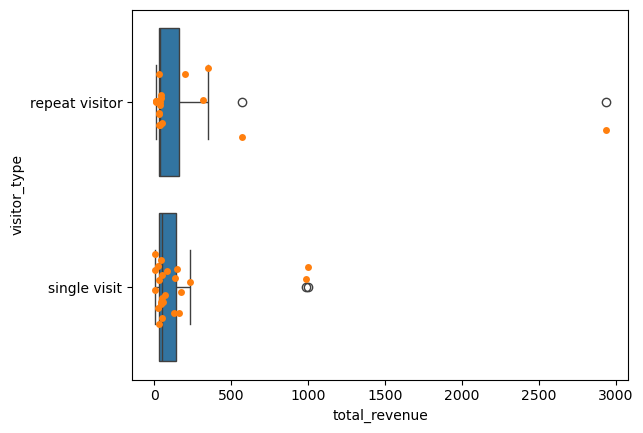

In [16]:
sns.boxplot(
    data = df_trx,
    x = 'total_revenue',
    y = 'visitor_type',    
)

# Use stripplot to see data distribution clearly, with it we can see each data's position clearly
sns.stripplot(
    data = df_trx,
    x = 'total_revenue',
    y = 'visitor_type',
    jitter=0.2
)
plt.show()


## Check Repeat Visitor Outlier Contribution to Revenue

In [17]:
# check what is the highest revenue of each visitor type?
df_trx.groupby('visitor_type')['total_revenue'].max().reset_index()
# df_trx.groupby(df['visitor_type']=='repeat visitor')['total_revenue'].max().reset_index()


,visitor_type,total_revenue
0,repeat visitor,2933.61
1,single visit,1000.78


In [18]:
# Now we calculate, what is the % contribution to revenue x / y * 100
rev_contribution_repeat_visitor = 2933.61 / 4754.67 * 100
rev_contribution_repeat_visitor

61.699550126507205

Based on the two plots above, there are outliers in both repeat visitor and single visit types. On repeat visitor, a revenue achieved 2933.61 of 4754.87 which means this outlier contribute to around 62% of revenue

In [19]:
# So we check the median
df_trx.groupby('visitor_type')['total_revenue'].median()

visitor_type
repeat visitor    34.395
single visit      48.385
Name: total_revenue, dtype: float64

Single-visit buyers' median is $48.385, they spend more than those of repeat-visitor buyers (median $34.395). This happens since median is not affected by outliers. The $22 average at the beginnning might be afffected by that one outlier data.

It rejects the first hypothesis, 'those who are repeat visitor tend to spend more', so SEO goal is not to target repeat visitors.

dari eksplorasi data, saya menemukan rata-rata awal yang tinggi ternyata didorong 1 outlier; setelah itu diperhitungkan (lewat median dan uji non-parametrik), pola sebenarnya adalah..."

## Hypothesis Testing with Mann-Whiteney Test
- Because the $48 median is just one sample, we need to test further (how confident the EDA result of the median above is not happening by conincidence) --> the goal isnt to proof repeat visitor > single visit (because it'll cause HARKING -- the researcher has seen the data, and therefore used it as confirmation)
- Using Mann-Whiteney U test, because the low sample count (only 18 paying trx for repeat visitor, and the data is skewed right or non-parametric)
- h0:  repeat visitor = single visit (probability of this happens due to luck 50:50) - because the mannwhiteney test treat data as rank, meaning we need to know 'if we pick a pair from two sides, and compare which side spend more, if the probability for repeat visit and single visit are equally 50:50, there there is no winner. P(random people from repeat visitor win vs. single visit) = 0.5 --> in other words: there is no group that is superior than the other
- ha: repeat visitor # single visit (but if the probability exceeds or less than 50:50 *e.g: one side always wins than the other it means it's not mere luck. P(random people from repeat visitor win vs. single visit) # 0.5 --> in other words: there is a tendency for one group to win


### Statistical Notes
- Significance/alpha = 0.05 or 5% /p-value
 - significance and alpha -> alpha: the confidence level of a test 'we are confidence 95% the test is valid, not random'   
 - p-value vs significance level: a test that has 0.05 alpha and the p-value 0.03 -> meaning this test is statistically significant because 0.03 <= 0.05.
- H0 -> null hypothesis, Ha-> what the researchers try to proof
- mann whiteney u compares the rank, not mean/proportion


In [20]:
group_single = df_trx[df_trx['visitor_type'] == 'single visit']['total_revenue']
group_repeat = df_trx[df_trx['visitor_type'] == 'repeat visitor']['total_revenue']

statistic, p_value = mannwhitneyu(group_single, group_repeat, alternative='two-sided')
print(statistic, p_value)
# Statistics or U stat is how many times group A beats B out of 432 probabilities, the closer the number to the actual pairs' mid point (18x24/2 = 216) meaning the closer to 50:50 probability (fail to reject H0)
# In the case above 'Statistics' is measured from single visit type since it is mentioned -> to know which group is dominant than the other: find the middle point of total data -> 18x24/2 = 216
# so in this case, single visit u stat is 241, more than 216, it's more dominant than repeat visitor (out of 432 probability, single visit win 241 times, compared to 191 wins for repeat visit)
# scipy always returns the first argument --> mannwhiteneyu(x, y) --> x is group single, so the result belongs to group single

241.0 0.5334634595222159


From the test, we get p-value of 0.533 which is larger than the accepted 0.05 (p-value > 0.05) meaning fail to reject the null hypthesis (the probability of random people from single visit win vs repeat visit is 50:50), similarly the u stat reflects out of 432 probability, single visit wins slightly 241 times from the expected 216 of pure chance (out of 432 chances). fail to reject h0, insuffiient proof to prove group 1 is superior than group 2, because we are not confident enough to say 'it's not because of luck' (p-value is exceeding the 0.05 alpha luck tolerance) if we take more samples, we cannot guarantee the same result.